# DroneRoute RL - Reinforcement Learning Experiments

This notebook analyzes the Q-Learning algorithm implemented in the DroneRoute RL project.

The purpose is to experimentally study how important reinforcement learning hyperparameters affect the learning performance of the drone agent.

## Parameters Studied

- Learning Rate (α)
- Discount Factor (γ)
- Epsilon (ε)
- Number of Training Episodes

The main Q-Learning implementation is available in `agent/q_learning.py`, while this notebook is used for experimentation, analysis, visualization, and viva demonstration.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np


# Get the DroneRoute-RL project root
PROJECT_ROOT = os.path.abspath("..")

# Allow this notebook to import project modules
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


from environment.drone_env import DroneEnvironment
from agent.q_learning import QLearningAgent


print("Project imports successful.")
print("Project root:", PROJECT_ROOT)

Project imports successful.
Project root: c:\Users\karam\Desktop\ARL\DroneRoute-RL


In [2]:
def run_experiment(
    episodes=1000,
    learning_rate=0.1,
    discount_factor=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    max_steps=100
):
    """
    Train a Q-Learning agent using the supplied hyperparameters.

    Returns training rewards, steps, success rate,
    environment, and trained agent.
    """

    env = DroneEnvironment()

    agent = QLearningAgent(
        grid_size=env.grid_size,
        learning_rate=learning_rate,
        discount_factor=discount_factor,
        epsilon=epsilon,
        epsilon_decay=epsilon_decay
    )

    rewards = []
    steps_history = []

    successful_episodes = 0

    for episode in range(episodes):

        state = env.reset()
        total_reward = 0

        for step in range(max_steps):

            # Choose an action
            action = agent.choose_action(state)

            # Perform the action
            next_state, reward, done = env.step(action)

            # Learn from the experience
            agent.update_q_value(
                state,
                action,
                reward,
                next_state,
                done
            )

            state = next_state
            total_reward += reward

            if done:
                successful_episodes += 1
                break

        rewards.append(total_reward)
        steps_history.append(step + 1)

        # Gradually reduce exploration
        agent.decay_epsilon()

    success_rate = (
        successful_episodes / episodes
    ) * 100

    return {
        "environment": env,
        "agent": agent,
        "rewards": rewards,
        "steps": steps_history,
        "success_rate": success_rate
    }


print("Experiment function ready.")

Experiment function ready.


In [3]:
baseline = run_experiment(
    episodes=1000,
    learning_rate=0.1,
    discount_factor=0.95,
    epsilon=1.0,
    epsilon_decay=0.995
)


baseline_average_reward = np.mean(
    baseline["rewards"][-100:]
)


print("=== Baseline Q-Learning Results ===")

print(
    "Success Rate:",
    f"{baseline['success_rate']:.2f}%"
)

print(
    "Final Epsilon:",
    round(
        baseline["agent"].epsilon,
        4
    )
)

print(
    "Average Reward (Last 100 Episodes):",
    round(
        baseline_average_reward,
        2
    )
)

=== Baseline Q-Learning Results ===
Success Rate: 99.00%
Final Epsilon: 0.01
Average Reward (Last 100 Episodes): 92.6


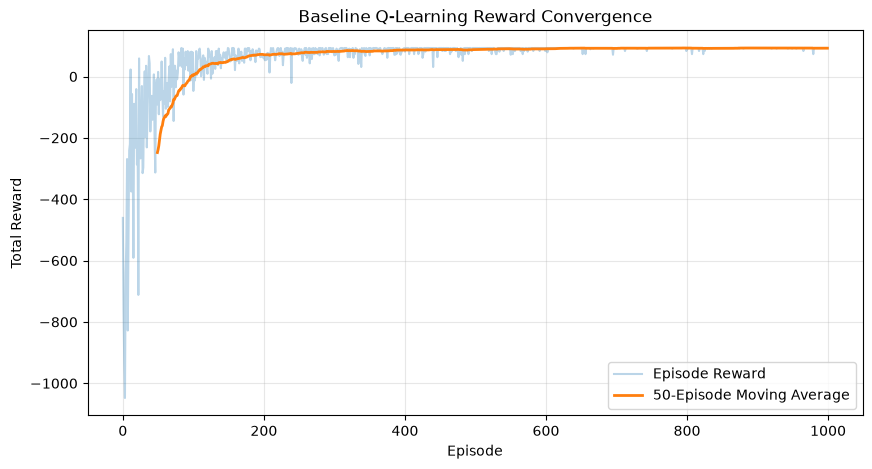

In [4]:
rewards = baseline["rewards"]

window_size = 50


moving_average = np.convolve(
    rewards,
    np.ones(window_size) / window_size,
    mode="valid"
)


plt.figure(figsize=(10, 5))

plt.plot(
    rewards,
    alpha=0.3,
    label="Episode Reward"
)

plt.plot(
    range(
        window_size - 1,
        len(rewards)
    ),
    moving_average,
    linewidth=2,
    label="50-Episode Moving Average"
)

plt.title(
    "Baseline Q-Learning Reward Convergence"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [5]:
q_table = baseline["agent"].q_table


print(
    "Q-table shape:",
    q_table.shape
)


print(
    "\nQ-values at starting state (0, 0):"
)

print(
    q_table[0, 0]
)


best_action = int(
    np.argmax(
        q_table[0, 0]
    )
)


action_names = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT"
}


print(
    "\nBest action from start:",
    action_names[best_action]
)

Q-table shape: (5, 5, 4)

Q-values at starting state (0, 0):
[47.74625226 28.11851441 48.47994895 63.80047553]

Best action from start: RIGHT


In [6]:
learning_rates = [
    0.01,
    0.1,
    0.5
]


learning_rate_results = {}


print("=== Learning Rate Experiment ===")


for learning_rate in learning_rates:

    result = run_experiment(
        episodes=1000,
        learning_rate=learning_rate,
        discount_factor=0.95,
        epsilon=1.0
    )

    learning_rate_results[
        learning_rate
    ] = result

    average_reward = np.mean(
        result["rewards"][-100:]
    )

    print(
        f"Alpha = {learning_rate} | "
        f"Success Rate = "
        f"{result['success_rate']:.2f}% | "
        f"Last 100 Avg Reward = "
        f"{average_reward:.2f}"
    )

=== Learning Rate Experiment ===
Alpha = 0.01 | Success Rate = 98.50% | Last 100 Avg Reward = 92.98
Alpha = 0.1 | Success Rate = 99.00% | Last 100 Avg Reward = 92.76
Alpha = 0.5 | Success Rate = 99.50% | Last 100 Avg Reward = 92.34


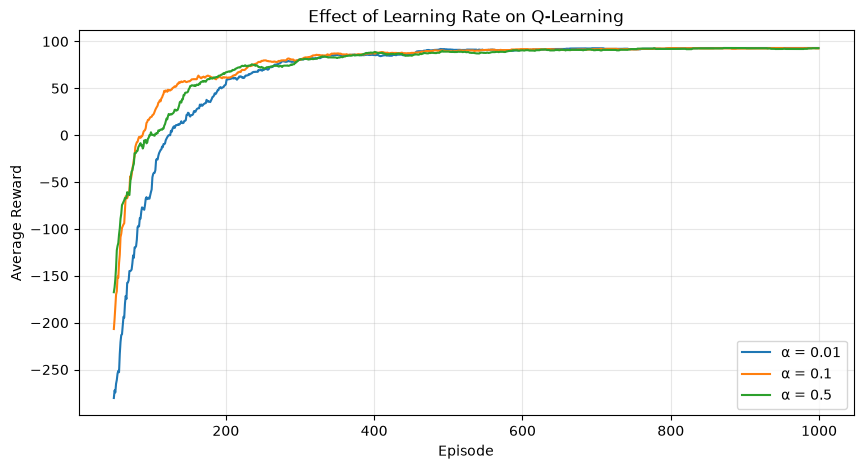

In [7]:
plt.figure(figsize=(10, 5))

window_size = 50


for learning_rate, result in learning_rate_results.items():

    rewards = result["rewards"]

    average = np.convolve(
        rewards,
        np.ones(window_size) / window_size,
        mode="valid"
    )

    plt.plot(
        range(
            window_size - 1,
            len(rewards)
        ),
        average,
        label=f"α = {learning_rate}"
    )


plt.title(
    "Effect of Learning Rate on Q-Learning"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [8]:
discount_factors = [
    0.5,
    0.8,
    0.95
]

discount_results = {}

print("=== Discount Factor Experiment ===")

for gamma in discount_factors:

    result = run_experiment(
        episodes=1000,
        learning_rate=0.1,
        discount_factor=gamma,
        epsilon=1.0
    )

    discount_results[gamma] = result

    average_reward = np.mean(
        result["rewards"][-100:]
    )

    print(
        f"Gamma = {gamma} | "
        f"Success Rate = {result['success_rate']:.2f}% | "
        f"Last 100 Avg Reward = {average_reward:.2f}"
    )

=== Discount Factor Experiment ===
Gamma = 0.5 | Success Rate = 99.40% | Last 100 Avg Reward = 92.60
Gamma = 0.8 | Success Rate = 98.90% | Last 100 Avg Reward = 92.36
Gamma = 0.95 | Success Rate = 99.50% | Last 100 Avg Reward = 92.62


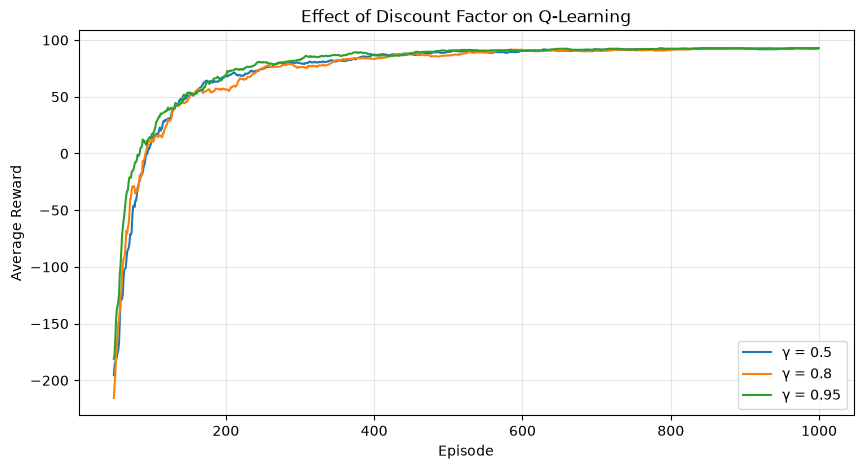

In [9]:
plt.figure(figsize=(10, 5))

window_size = 50

for gamma, result in discount_results.items():

    rewards = result["rewards"]

    average = np.convolve(
        rewards,
        np.ones(window_size) / window_size,
        mode="valid"
    )

    plt.plot(
        range(window_size - 1, len(rewards)),
        average,
        label=f"γ = {gamma}"
    )

plt.title("Effect of Discount Factor on Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [10]:
epsilon_values = [
    0.3,
    0.7,
    1.0
]

epsilon_results = {}

print("=== Epsilon Experiment ===")

for epsilon in epsilon_values:

    result = run_experiment(
        episodes=1000,
        learning_rate=0.1,
        discount_factor=0.95,
        epsilon=epsilon
    )

    epsilon_results[epsilon] = result

    average_reward = np.mean(
        result["rewards"][-100:]
    )

    print(
        f"Epsilon = {epsilon} | "
        f"Success Rate = {result['success_rate']:.2f}% | "
        f"Last 100 Avg Reward = {average_reward:.2f}"
    )

=== Epsilon Experiment ===
Epsilon = 0.3 | Success Rate = 99.90% | Last 100 Avg Reward = 92.36
Epsilon = 0.7 | Success Rate = 99.90% | Last 100 Avg Reward = 92.84
Epsilon = 1.0 | Success Rate = 99.10% | Last 100 Avg Reward = 92.68


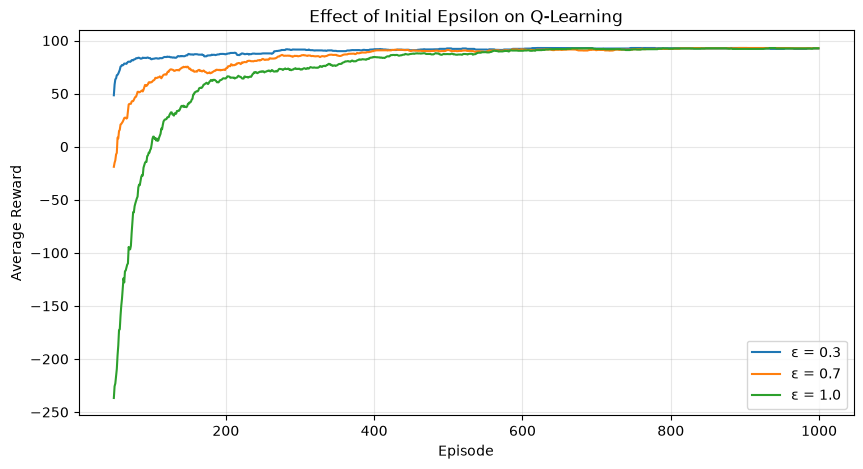

In [11]:
plt.figure(figsize=(10, 5))

window_size = 50

for epsilon, result in epsilon_results.items():

    rewards = result["rewards"]

    average = np.convolve(
        rewards,
        np.ones(window_size) / window_size,
        mode="valid"
    )

    plt.plot(
        range(window_size - 1, len(rewards)),
        average,
        label=f"ε = {epsilon}"
    )

plt.title("Effect of Initial Epsilon on Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [12]:
episode_counts = [
    100,
    500,
    1000
]

episode_results = {}

print("=== Episode Count Experiment ===")

for episodes in episode_counts:

    result = run_experiment(
        episodes=episodes,
        learning_rate=0.1,
        discount_factor=0.95,
        epsilon=1.0
    )

    episode_results[episodes] = result

    average_reward = np.mean(
        result["rewards"][-100:]
    )

    print(
        f"Episodes = {episodes} | "
        f"Success Rate = {result['success_rate']:.2f}% | "
        f"Final Avg Reward = {average_reward:.2f}"
    )

=== Episode Count Experiment ===
Episodes = 100 | Success Rate = 93.00% | Final Avg Reward = -116.31
Episodes = 500 | Success Rate = 97.60% | Final Avg Reward = 89.76
Episodes = 1000 | Success Rate = 99.60% | Final Avg Reward = 92.86


In [13]:
print("=== Final Hyperparameter Summary ===")

print("\nBaseline:")
print("Learning Rate (α): 0.1")
print("Discount Factor (γ): 0.95")
print("Initial Epsilon (ε): 1.0")
print("Episodes: 1000")

print(
    "\nBaseline Success Rate:",
    f"{baseline['success_rate']:.2f}%"
)

print(
    "Baseline Last 100 Avg Reward:",
    round(
        np.mean(baseline["rewards"][-100:]),
        2
    )
)

=== Final Hyperparameter Summary ===

Baseline:
Learning Rate (α): 0.1
Discount Factor (γ): 0.95
Initial Epsilon (ε): 1.0
Episodes: 1000

Baseline Success Rate: 99.00%
Baseline Last 100 Avg Reward: 92.6


## Final Observations

The Q-Learning agent successfully learned an efficient delivery route in the custom drone environment.

### Key Findings

- The agent improved from low initial rewards to rewards close to the theoretical optimum.
- Lower learning rates resulted in slower convergence.
- A high discount factor was suitable because route optimization requires considering future rewards.
- Epsilon-greedy exploration helped the agent discover useful routes before gradually exploiting learned Q-values.
- Increasing the number of episodes improved convergence and route reliability.
- The trained Q-table successfully produced an optimal 8-step route to the delivery destination.

These experiments demonstrate how Q-Learning hyperparameters influence reinforcement learning performance.